# Setup

In [1]:
import torch
import time
import random
from typing import Tuple
from tqdm import tqdm

import numpy as np
import pandas as pd
from scapy.all import raw, PcapReader, Ether
import seaborn as sns
import matplotlib.pyplot as plt

import time
from typing import Counter, Tuple
import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import confusion_matrix

In [2]:
DEFAULT_SEED = 10

torch.manual_seed(DEFAULT_SEED)
torch.cuda.manual_seed_all(DEFAULT_SEED)
torch.cuda.manual_seed(DEFAULT_SEED)
torch.mps.manual_seed(DEFAULT_SEED)
np.random.seed(DEFAULT_SEED)
random.seed(DEFAULT_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
def get_overall_metrics(y_true, y_pred):
  tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
  acc = (tp+tn)/(tp+tn+fp+fn)
  tpr = tp/(tp+fn)
  fpr = fp/(fp+tn)
  precision = tp/(tp+fp)
  f1 = (2*tpr*precision)/(tpr+precision)
  return {'acc':acc,'tpr':tpr,'fpr':fpr,'precision':precision,'f1-score':f1}

def plot_confusion_matrix(y_true, y_pred):
  cm = confusion_matrix(y_true, y_pred)
  group_counts = [f'{value:.0f}' for value in confusion_matrix(y_true, y_pred).ravel()]
  group_percentages = [f'{value*100:.2f}%' for value in confusion_matrix(y_true, y_pred).ravel()/np.sum(cm)]
  labels = [f'{v1}\n{v2}' for v1, v2 in zip(group_counts, group_percentages)]
  labels = np.array(labels).reshape(2,2)
  sns.heatmap(cm, annot=labels, cmap='Oranges', xticklabels=['Predicted Benign', 'Predicted Malicious'], yticklabels=['Actual Benign', 'Actual Malicious'], fmt='')
  return

def get_tpr_per_attack(y_labels, y_pred):
  aux_df = pd.DataFrame({'Label':y_labels,'prediction':y_pred})
  total_per_label = aux_df['Label'].value_counts().to_dict()
  correct_predictions_per_label = aux_df.query('Label != "Normal" and prediction == True').groupby('Label').size().to_dict()
  tpr_per_attack = {}
  for attack_label, total in total_per_label.items():
    if attack_label == 'Normal':
      continue
    tp = correct_predictions_per_label[attack_label] if attack_label in correct_predictions_per_label else 0
    tpr = tp/total
    tpr_per_attack[attack_label] = tpr
  return tpr_per_attack

# Carregando os dados

In [39]:
cache = torch.load(f"train_data_processed_avtp.pt", weights_only=False)
X_train_flat, y_train = cache['X_train_flat'], cache['y_train']

In [40]:
X_train_flat.shape

(287024, 58)

In [41]:
df_feat = pd.DataFrame(X_train_flat, columns=[f"f{i}" for i in range(58)])
cols_with_std = df_feat.std() > 0
selected_cols = df_feat.columns[cols_with_std]
important_features = selected_cols

<Axes: ylabel='Frequency'>

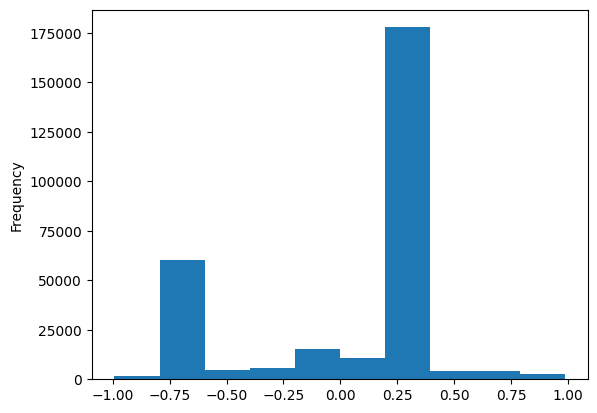

In [50]:
df_feat['f20'].plot.hist()

In [42]:
important_features = [int(i[1:]) for i in important_features]

## 1. Teste de Normalidade (Shapiro-Wilk)

Verifica se as features seguem distribuição normal.

In [17]:
from scipy.stats import shapiro

# Teste de normalidade para algumas features importantes
print("Teste de Normalidade (Shapiro-Wilk)")
print("=" * 50)
print(f"H0: Os dados seguem distribuição normal")
print(f"H1: Os dados não seguem distribuição normal")
print(f"Nível de significância: α = 0.05\n")

for feat_idx in important_features:
    sample = X_train_flat[:, feat_idx][:5000]  # Amostra limitada
    stat, p_value = shapiro(sample)
    result = "Rejeita H0" if p_value < 0.05 else "Não rejeita H0"
    print(f"Feature {feat_idx}: p-value = {p_value:.6f} -> {result}")

Teste de Normalidade (Shapiro-Wilk)
H0: Os dados seguem distribuição normal
H1: Os dados não seguem distribuição normal
Nível de significância: α = 0.05

Feature 0: p-value = 1.000000 -> Não rejeita H0
Feature 1: p-value = 1.000000 -> Não rejeita H0
Feature 2: p-value = 1.000000 -> Não rejeita H0
Feature 3: p-value = 1.000000 -> Não rejeita H0
Feature 4: p-value = 1.000000 -> Não rejeita H0
Feature 5: p-value = 1.000000 -> Não rejeita H0
Feature 6: p-value = 1.000000 -> Não rejeita H0
Feature 7: p-value = 1.000000 -> Não rejeita H0
Feature 8: p-value = 1.000000 -> Não rejeita H0
Feature 9: p-value = 1.000000 -> Não rejeita H0
Feature 10: p-value = 1.000000 -> Não rejeita H0
Feature 11: p-value = 1.000000 -> Não rejeita H0
Feature 12: p-value = 1.000000 -> Não rejeita H0
Feature 13: p-value = 1.000000 -> Não rejeita H0
Feature 14: p-value = 1.000000 -> Não rejeita H0
Feature 15: p-value = 1.000000 -> Não rejeita H0
Feature 16: p-value = 1.000000 -> Não rejeita H0
Feature 17: p-value = 0

/Users/mauriciosightman/Documents/Work/master/RABID/.venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


## 2. Teste de Mann-Whitney U

Compara a distribuição de cada feature entre tráfego normal e ataques.

In [44]:
from scipy.stats import mannwhitneyu

# Separar dados normais e ataques
normal_mask = y_train['label'] == 'Normal'
attack_mask = y_train['label'] == 'Frame Injection'

print("\nTeste de Mann-Whitney U (Normal vs Ataques)")
print("=" * 50)
print(f"H0: As distribuições são iguais")
print(f"H1: As distribuições são diferentes")
print(f"Nível de significância: α = 0.05\n")

very_important_features = []

for feat_idx in important_features:
    normal_data = X_train_flat[normal_mask, feat_idx]
    attack_data = X_train_flat[attack_mask, feat_idx]
    stat, p_value = mannwhitneyu(normal_data, attack_data, alternative='two-sided')
    result = "Rejeita H0 (diferença significativa)" if p_value < 0.05 else "Não rejeita H0"
    if p_value < 0.05:
        very_important_features.append(feat_idx)
    print(f"Feature {feat_idx}: p-value = {p_value:.6e} -> {result}")


Teste de Mann-Whitney U (Normal vs Ataques)
H0: As distribuições são iguais
H1: As distribuições são diferentes
Nível de significância: α = 0.05

Feature 1: p-value = 8.401867e-01 -> Não rejeita H0
Feature 2: p-value = 8.401867e-01 -> Não rejeita H0
Feature 3: p-value = 8.401867e-01 -> Não rejeita H0
Feature 4: p-value = 8.401867e-01 -> Não rejeita H0
Feature 11: p-value = 7.755041e-01 -> Não rejeita H0
Feature 12: p-value = 8.401867e-01 -> Não rejeita H0
Feature 13: p-value = 8.401867e-01 -> Não rejeita H0
Feature 14: p-value = 8.401867e-01 -> Não rejeita H0
Feature 15: p-value = 8.401867e-01 -> Não rejeita H0
Feature 16: p-value = 8.401867e-01 -> Não rejeita H0
Feature 17: p-value = 8.401867e-01 -> Não rejeita H0
Feature 19: p-value = 8.401867e-01 -> Não rejeita H0
Feature 20: p-value = 0.000000e+00 -> Rejeita H0 (diferença significativa)
Feature 22: p-value = 8.401867e-01 -> Não rejeita H0
Feature 23: p-value = 8.401663e-01 -> Não rejeita H0
Feature 24: p-value = 8.401867e-01 -> Nã

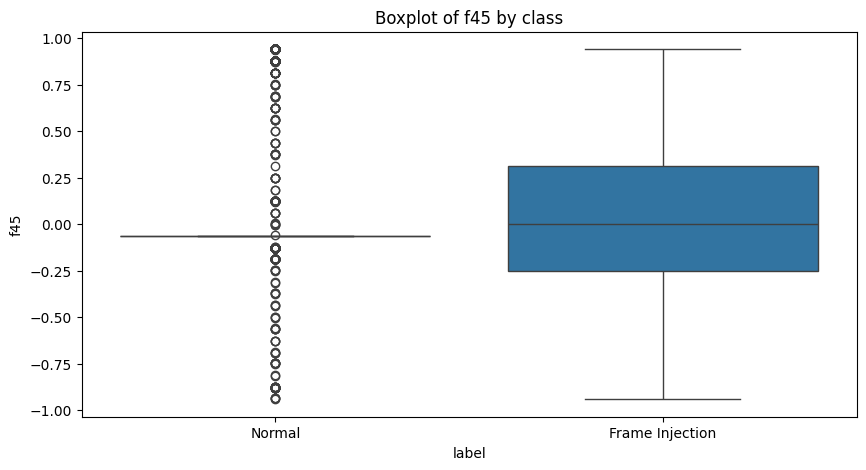

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in df_feat.columns:
    if '45' in col:
        plt.figure(figsize=(10,5))
        sns.boxplot(x=y_train["label"], y=df_feat[col])
        plt.title(f"Boxplot of {col} by class")
        plt.show()

In [35]:
len(very_important_features)

2

## 4. Teste de Correlação (Spearman)

Verifica se há correlação entre as features mais importantes identificadas pelo modelo.

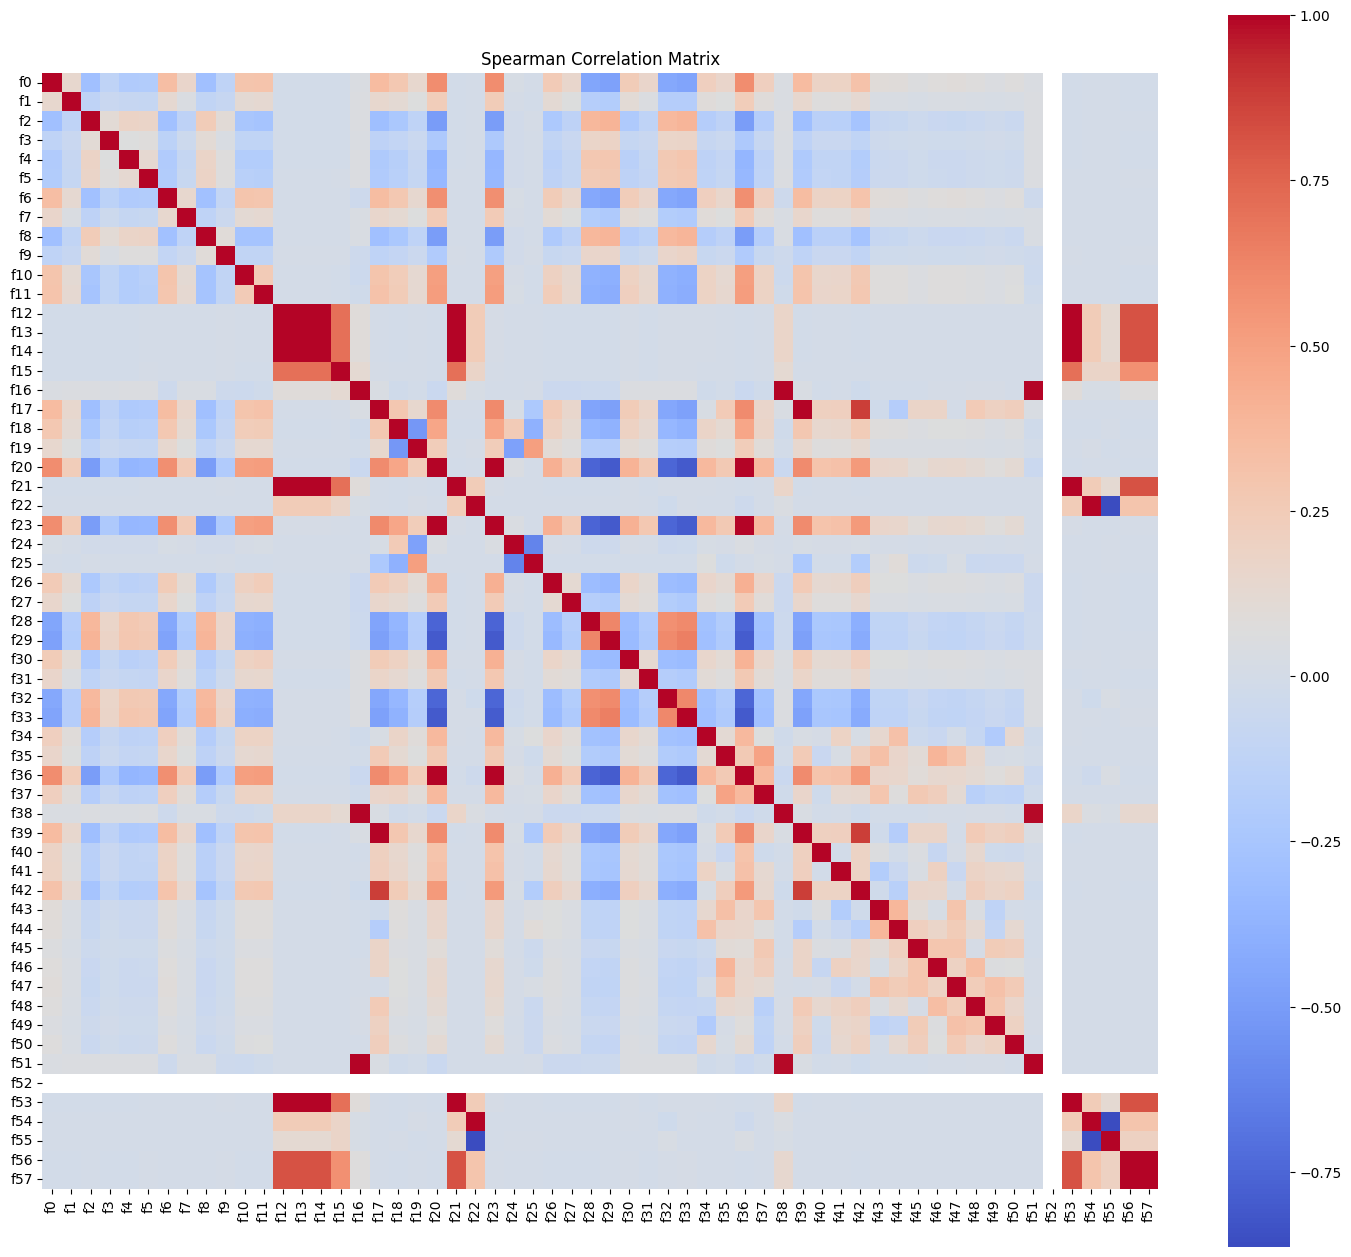

In [27]:
# Compute Spearman correlation matrix
corr_spearman = df_feat.corr(method="spearman", numeric_only=True)

# Plot Spearman correlation heatmap
plt.figure(figsize=(18,16))
sns.heatmap(corr_spearman, cmap="coolwarm", square=True)
plt.title("Spearman Correlation Matrix")
plt.show()

In [23]:
from scipy.stats import spearmanr

print("\nTeste de Correlação de Spearman")
print("=" * 50)
print(f"H0: Não há correlação entre as features")
print(f"H1: Há correlação entre as features")
print(f"Nível de significância: α = 0.05\n")

# Matriz de correlação para features importantes
for i in range(len(very_important_features)):
    for j in range(i+1, len(very_important_features)):
        feat_i, feat_j = very_important_features[i], very_important_features[j]
        corr, p_value = spearmanr(X_train_flat[:, feat_i], X_train_flat[:, feat_j])
        result = "Rejeita H0 (correlação significativa)" if p_value < 0.05 else "Não rejeita H0"
        print(f"Feature {feat_i} vs {feat_j}:\t ρ = {corr:.4f},\t p-value = {p_value:.6e} -> \t\t{result}")


Teste de Correlação de Spearman
H0: Não há correlação entre as features
H1: Há correlação entre as features
Nível de significância: α = 0.05

Feature 22 vs 32:	 ρ = -0.0282,	 p-value = 9.491809e-147 -> 		Rejeita H0 (correlação significativa)
Feature 22 vs 34:	 ρ = 0.0003,	 p-value = 7.806625e-01 -> 		Não rejeita H0
Feature 22 vs 35:	 ρ = 0.0008,	 p-value = 4.537804e-01 -> 		Não rejeita H0
Feature 22 vs 36:	 ρ = -0.0398,	 p-value = 1.466498e-291 -> 		Rejeita H0 (correlação significativa)
Feature 22 vs 37:	 ρ = 0.0006,	 p-value = 5.824977e-01 -> 		Não rejeita H0
Feature 22 vs 40:	 ρ = -0.0020,	 p-value = 6.502444e-02 -> 		Não rejeita H0
Feature 22 vs 42:	 ρ = -0.0029,	 p-value = 7.508805e-03 -> 		Rejeita H0 (correlação significativa)
Feature 22 vs 43:	 ρ = -0.0006,	 p-value = 5.991799e-01 -> 		Não rejeita H0
Feature 22 vs 44:	 ρ = -0.0001,	 p-value = 9.460916e-01 -> 		Não rejeita H0
Feature 22 vs 45:	 ρ = -0.0017,	 p-value = 1.286901e-01 -> 		Não rejeita H0
Feature 22 vs 46:	 ρ = -0.000

KeyboardInterrupt: 

## 5. Teste de Permutação para Feature Importance

Valida estatisticamente se a importância das features é significativa.

In [ ]:
print("\nTeste de Permutação - Feature Importance")
print("=" * 50)
print(f"H0: A feature não tem importância real (baseline)")
print(f"H1: A feature tem importância significativa")
print(f"Nível de significância: α = 0.05\n")

# Usar resultados do PFI já calculado (variável 'train_result' da célula 59)
# Primeiro, vamos obter o PFI novamente para o conjunto de validação
from sklearn.inspection import permutation_importance
pfi_result = permutation_importance(rf, X_val_sub, y_val_sub, n_repeats=50, random_state=DEFAULT_SEED)

baseline_score = rf.score(X_val_sub, y_val_sub)
print(f"Baseline accuracy: {baseline_score:.4f}\n")

# Verificar importância vs erro padrão
for feat_idx in important_features:
    mean_importance = pfi_result.importances_mean[feat_idx]
    std_importance = pfi_result.importances_std[feat_idx]
    
    # Teste estatístico: importância / erro padrão (t-statistic aproximado)
    if std_importance > 0:
        t_stat = mean_importance / std_importance
        significant = t_stat > 1.96  # Aproximadamente 95% de confiança
        result_text = "Significativa" if significant else "Não significativa"
        print(f"Feature {feat_idx}: importance = {mean_importance:.6f} ± {std_importance:.6f} (t = {t_stat:.2f}) -> {result_text}")
    else:
        print(f"Feature {feat_idx}: importance = {mean_importance:.6f} (sem variação)")

# Random Forest

In [65]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier().fit(X_train_flat, y_train['label'])

KeyboardInterrupt: 

In [57]:
df_feat[selected_cols[:-8]].head()

,f1,f2,f3,f4,f11,f12,f13,f14,f15,f16,...,f37,f38,f39,f40,f41,f42,f43,f44,f45,f46
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.062745,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.062745,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.062745,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.062745,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.062745,0.0


In [54]:
Yhat_dt = dt.predict(df_feat[selected_cols[:-8]])

In [55]:
get_overall_metrics(y_train['label'], Yhat_dt)

{'acc': np.float64(0.9236579519482692),
 'tpr': np.float64(0.935597603057073),
 'fpr': np.float64(0.12113837290155956),
 'precision': np.float64(0.966641439929973),
 'f1-score': np.float64(0.9508662095316682)}

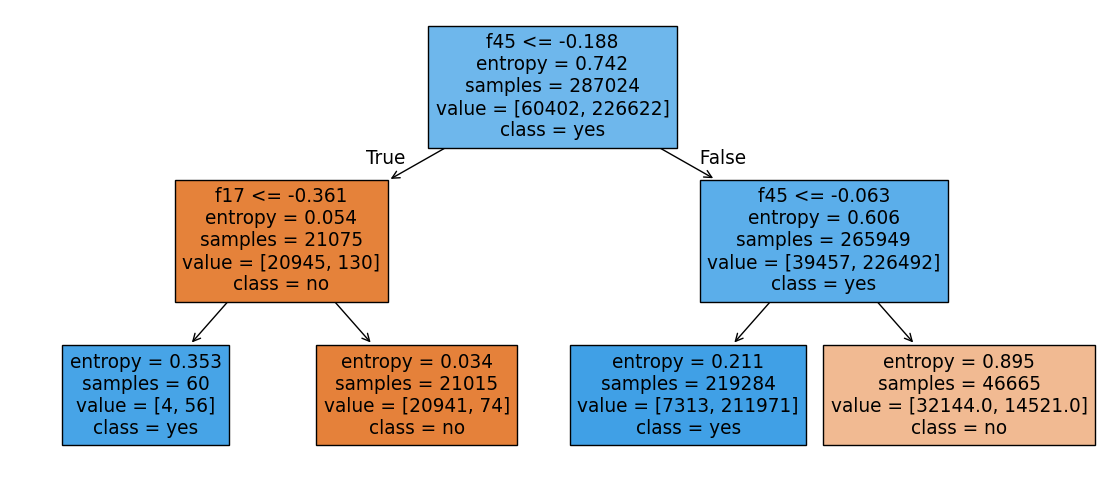

In [58]:
from sklearn import tree

plt.figure(figsize=(14, 6))
tree.plot_tree(dt, class_names=['no', 'yes'], feature_names=df_feat[selected_cols[:-8]].columns, filled=True)

plt.show()